# Setup and Import

In [20]:
# Import libraries.
import os

import pandas as pd
from matplotlib.backends.backend_qt import NavigationToolbar2QT

print(f"Pandas version: {pd.__version__}")

import numpy as np
print(f"Numpy version: {np.__version__}")

import openpyxl
print(f"Openpyxl version: {openpyxl.__version__}")

# When importing a sub-module so we don't do version checking on it directly.
# For graphing.
import matplotlib.pyplot as plt

# For data validation.
import pandera.pandas as pa

# This allows the notebook to see the utilities.py in the root folder
# sys.path.append("..")
# import utilities

Pandas version: 2.3.3
Numpy version: 2.2.6
Openpyxl version: 3.1.5


In [12]:
# Set some options for pandas so that it doesn't truncate the dataframe view window.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

In [11]:
# Import the raw data.
file_path = os.path.join('..', 'Data', 'Updated_NSQIP_83083.xlsx')
df = pd.read_excel(file_path)

# Data Cleaning

In [14]:
# Make a copy of the raw data frame, but only keep the specific columns we want.
columns_to_keep = ["PUFYEAR","OPTIME","AGE","SEX"]
NSQIP_subset_df = df[[column for column in columns_to_keep if column in df.columns]].copy()

In [15]:
NSQIP_subset_df.head(5)

,PUFYEAR,OPTIME,AGE,SEX
0,2014,120,25.0,male
1,2014,95,31.0,male
2,2014,66,27.0,male
3,2014,49,43.0,male
4,2014,90,19.0,male


We want to check for any rows with missing values or values that don't seem reasonable or trustworthy based on the domain-specific knowledge.

For this, I'll use a library called Pandera to set ranges ahead of time and get an idea of how many rows have problems.

In [39]:
# We define the expectations of our values.
schema = pa.DataFrameSchema({
    # PUFYEAR values should be greater than 1990 and before the current year and not null.
    "PUFYEAR": pa.Column(
        int,
        checks=pa.Check.in_range(1990, 2025),
        nullable=False
    ),
    # OPTIME values should be greater than zero and not null.
    "OPTIME": pa.Column(
        float,
        checks=pa.Check.gt(0),
        nullable=False,
        coerce=True # If we get ints make them into floats.
    ),
    # Age range values - in years - should be, at most, between 0 and 120 and not null.
    "AGE": pa.Column(
        float,
        checks=pa.Check.in_range(0, 120),
    ),
    # SEX should be either 'male' or 'female' and not null.
    "SEX": pa.Column(
        str, pa.Check.isin(["male", "female"]),
        nullable=False
    )
})

In [44]:
# Let's view a summary of any errors.
# I'll save this as a function so it can be re-used below.
def check_subset_data(dataframe, print_rows=False):
    # Look for errors according to the defined schema.
    try:
        schema.validate(dataframe, lazy=True)
    # If errors are found, we get an exception.
    except pa.errors.SchemaErrors as err:
        # A 'failures' dataframe is returned.
        failures_df = err.failure_cases

        # If desired, we could print the errors out and see information about where they are in the data frame.
        if print_rows:
            print("Rows with Validation Errors:")
            print(failures_df)

        # We aggregate the failures by column, check, and failure case.
        summary_df = (
            failures_df.groupby(["column", "check", "failure_case"], dropna=False)
           .size()
           .reset_index(name="count")
           .sort_values("count", ascending=False)
        )
        # Print out the summary.
        print("Summary of Validation Errors:")
        print(summary_df)
    # If no errors are found, notify us that this is the case.
    else:
        print("No errors found.")

In [42]:
# Call the function defined above.
check_subset_data(NSQIP_subset_df)

Summary of Validation Errors:
   column            check  failure_case  count
2  OPTIME  greater_than(0)           0.0     95
0     AGE     not_nullable           NaN     63
1  OPTIME  greater_than(0)         -99.0     11


In [25]:
# Let's check how many total rows we have.
NSQIP_subset_df.shape[0]

83083

Since we have 83,083 total rows and - at most - less than 200 rows with bad values, we can just drop those rows for now. It shouldn't have any significant impact on the data for what we're doing now, though in a real-world scenario we may want to inspect them individually and determine if we can retrieve or fix the missing info and/or make sure we're not removing any rows with huge outlier values.

In [26]:
# Drop the rows with errors.
# Note: "AGE == AGE" is a trick to filter out NaNs (because NaN never equals itself)
NSQIP_subset_df_clean = NSQIP_subset_df.query("OPTIME != 0 and OPTIME != -99 and AGE == AGE")

In [45]:
# Check again
check_subset_data(NSQIP_subset_df_clean,print_rows=True)

No errors found.


In class we used a SQL style join to add aggregation info to each row. That method can be done using similar Pandas operations in Python, but there's a more direct way called 'broadcasting' that I can use here.

In [46]:
# The [:, 'ColumnName'] tells Pandas: "Select ALL rows (:), and THIS specific column"
NSQIP_subset_df_clean = NSQIP_subset_df_clean.copy()
NSQIP_subset_df_clean['Mean(OPTIME)'] = NSQIP_subset_df_clean.groupby(['SEX', 'PUFYEAR'])['OPTIME'].transform('mean')

In [47]:
# We can get a similar summary to what we have in JMP as well.
# Create a new summary dataframe
summary_table = NSQIP_subset_df_clean.groupby(['PUFYEAR', 'SEX'])['OPTIME'].agg(
    N_Rows='count',          # This creates the "N Rows" column
    Mean_OPTIME='mean'       # This creates the "Mean(OPTIME)" column
).reset_index()              # This flattens the index so it looks like a normal table

# View the table
display(summary_table)

,PUFYEAR,SEX,N_Rows,Mean_OPTIME
0,2012,female,4681,37.731895
1,2012,male,5466,46.003476
2,2013,female,5973,41.111502
3,2013,male,6930,46.144733
4,2014,female,7017,41.380790
5,2014,male,8998,51.172927
6,2015,female,9039,40.669101
7,2015,male,11134,49.072032
8,2016,female,10494,41.110539
9,2016,male,13183,52.274293


From here we can move on to creating our visualizations.

# Graphs

We can create some simple histograms using Pandas functions that point directly at Matplotlib.

Here is a basic one:

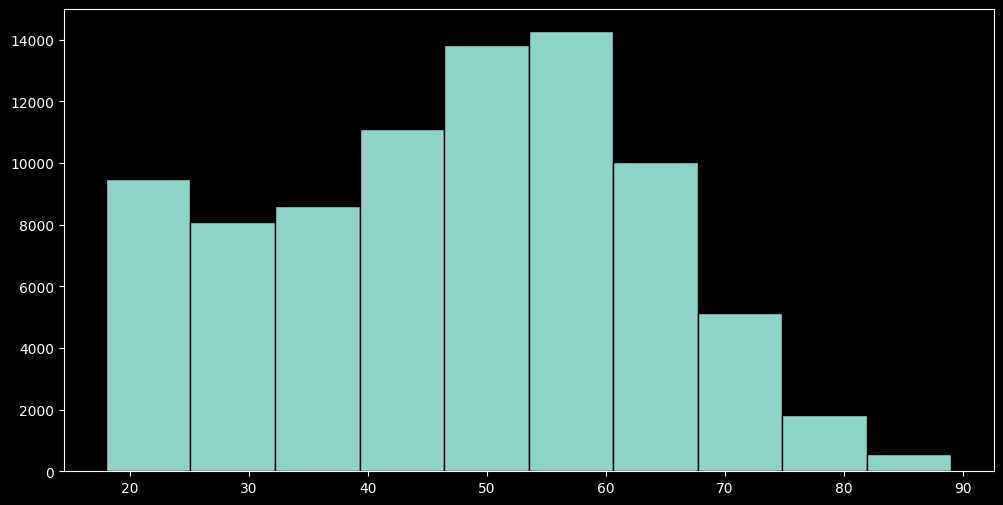

In [49]:
NSQIP_subset_df_clean['AGE'].hist(
    #by=NSQIP_subset_df_clean['SEX'],
    figsize=(12, 6),
    bins=10,
    edgecolor='black',
    #density=True,
    grid=False
    );

We can split by groups using the 'by=' logic, and add some graph titles etc:

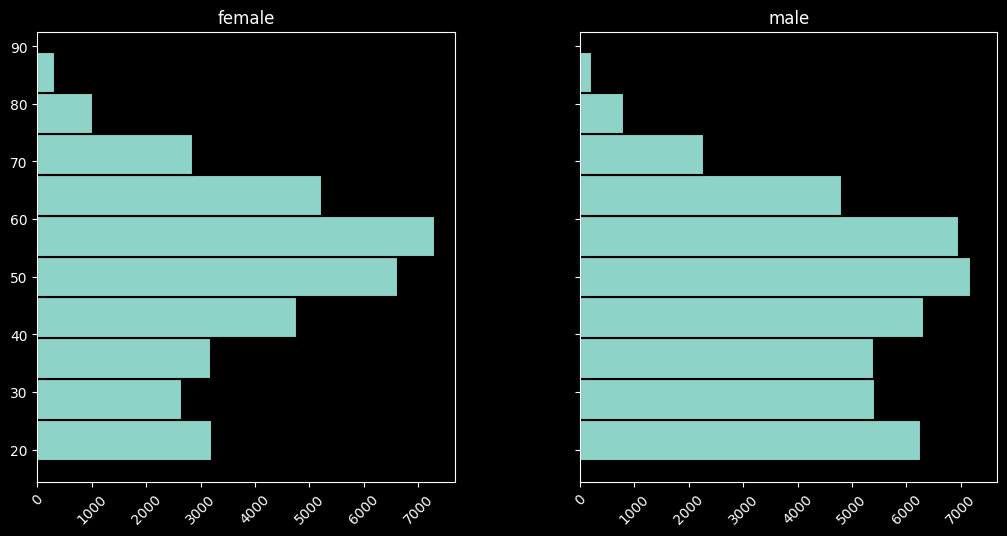

In [50]:
NSQIP_subset_df_clean['AGE'].hist(
    by=NSQIP_subset_df_clean['SEX'],
    sharex=True, # Makes sure the subplots keep the same domains.
    sharey=True, # Makes sure the subplots keep the same ranges.
    figsize=(12, 6),
    bins=10,
    edgecolor='black',
    #density=True,
    #grid=False,
    xrot=45,
    #log=True, # Makes the y axis log based.
    orientation='horizontal',
    linewidth=1.5, # Bar Border Thickness
    #linestyle='--', # Bar Border Style
    #hatch='//', # Fill the bars with diagonal lines instead of solid color.
    #cumulative=True, # Turns the histogram into a CDF. Bars keep adding until they hit 1.
    );

The Plotly library allows for more interactive graphs and dashboards:

In [61]:
import plotly.express as px

fig = px.histogram(
    NSQIP_subset_df_clean,
    x="AGE",
    color="SEX",
    nbins=10,
    barmode="overlay",
    opacity=0.6,
    range_x=[15, 100],
    color_discrete_sequence=['#1f77b4', '#d62728'],
    width=1500,
    height=900,
)

# Update the Graph Settings
fig.update_layout(

    # Legend Settings
    legend=dict(
        title="Patient Sex", # Rename the legend title
        title_font=dict(
            size=12,
            color='black',
        ),
        orientation="v",     # "h" = horizontal, "v" = vertical
        y=1,              # Y>1 moves it above the plot
        x=1,                 # X=1 moves it to the right
        xanchor="right",
        yanchor="bottom"
    ),

    # Graph Title Settings
    title=dict(
      text="Distribution of Operation Time by Sex",
      y=0.95,
      x=0.5,
      xanchor='center',
      yanchor='top',
    ),

    # Background Color
    plot_bgcolor='rgba(240, 240, 240, 0.5)', # Light Gray with 50% opacity

    # X-Axis Settings
    xaxis = dict(
        title="Patient Age (Years)",
        title_font=dict(
            size=18,
            color='black',
        ),
        dtick=10,
        tickangle=-45,
        #showgrid=True,
        #gridcolor='lightgray',
        #gridwidth=1,
        zeroline=True, # Darker line at 0.
        zerolinecolor='black',
        linewidth=1.25, # Thickness of the axis line itself.
        linecolor='black', # Color of the axis line itself.
    ),

    # Y-Axis Settings
    yaxis = dict(
        title="Number of Patients",
        title_font=dict(
            size=18,
            color='black',
        ),
        type='linear',
        dtick=1000,
        zeroline=True,
        zerolinecolor='black',
        linewidth=1.25,
        linecolor='black',
    )
  )
fig.show()

In [59]:
# This code is typed into the terminal:
# quarto render Notebooks/modules_0_and_1.ipynb --output-dir Outputs --output Assignment_1_Report.pdf